# Pathway-informed integration of bulk TCGA-BRCA multi-omics

We integrate bulk RNA-seq and reverse-phase protein array (RPPA) data from primary breast tumours in [The Cancer Genome Atlas (TCGA)](https://www.cancer.gov/ccg/research/genome-sequencing/tcga) with a single MOFA-FLEX model. Hallmark gene sets guide the RNA weights through an informed prior, so the factors come out as named, pathway-anchored programs rather than anonymous components.

We then show that these programs:

1. recover the Hallmark pathways they were seeded with,
2. recapitulate the PAM50 molecular subtypes and ER status, which the model never sees,
3. stratify patient overall survival, and
4. carry protein signatures that independently corroborate the RNA-driven biology.

## Load libraries and data

In [1]:
import os.path
import tempfile
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve

import anndata as ad
import matplotlib.pyplot as plt
import mofaflex as mfl
import mudata as md
import numpy as np
import pandas as pd
import scanpy as sc
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from plotnine import *
from statsmodels.stats.multitest import multipletests

theme_set(theme_bw())
md.set_options(display_style="html", display_html_expand=0, pull_on_update=False)
# These dense tutorial matrices are small enough to process eagerly.
mfl.settings.use_dask = False

/home/aqoku/miniforge3/envs/mfl/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



We download gene expression, protein abundance, and clinical annotations from [UCSC Xena](https://xenabrowser.net/datapages/). Xena matrices store features in rows and samples in columns, and the expression and RPPA matrices are gzip-compressed.

In [2]:
urls = {
    "rna": "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.BRCA.sampleMap%2FHiSeqV2.gz",
    "rppa": "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.BRCA.sampleMap%2FRPPA_RBN.gz",
    "clinical": "https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/TCGA.BRCA.sampleMap%2FBRCA_clinicalMatrix",
}

with TemporaryDirectory() as tmpdir:
    paths = {}
    for name, url in urls.items():
        path = os.path.join(tmpdir, name)
        urlretrieve(url, path)
        paths[name] = path

    # The expression and RPPA matrices are gzip-compressed; the clinical matrix is plain text.
    rna = pd.read_table(paths["rna"], index_col=0, compression="gzip").T
    rppa = pd.read_table(paths["rppa"], index_col=0, compression="gzip").T
    clinical = pd.read_table(paths["clinical"], index_col="sampleID", low_memory=False)

TCGA sample barcodes encode the sample type in characters 14–15, where `01` denotes a primary tumour. We keep primary tumours, select the 5,000 most variable genes, and keep all non-constant RPPA features.

In [3]:
rna = rna.loc[rna.index.str[13:15] == "01"]
rna_variance = rna.var(axis=0)
rna = rna.loc[:, rna_variance[rna_variance > 0].nlargest(5_000).index].astype("float32")

rppa = rppa.loc[rppa.index.str[13:15] == "01"]
rppa = rppa.loc[:, rppa.var(axis=0) > 0].astype("float32")
# MuData requires globally unique variable names across modalities.
rppa.columns = "RPPA:" + rppa.columns

We attach PAM50 subtype, receptor status, and overall-survival annotations. These are clinical ground truth, derived independently of the omics data, and we use them only to validate the model after training — they never enter it.

In [4]:
clinical = clinical.rename(
    columns={
        "PAM50Call_RNAseq": "PAM50",
        "ER_Status_nature2012": "ER status",
        "HER2_Final_Status_nature2012": "HER2 status",
        "PR_Status_nature2012": "PR status",
    }
)
clinical["PAM50"] = pd.Categorical(clinical["PAM50"], categories=["Basal", "Her2", "LumA", "LumB", "Normal"])
# Overall survival: time to death for deceased patients, otherwise time to last follow-up.
clinical["OS_event"] = (clinical["vital_status"] == "DECEASED").astype(float)
clinical["OS_time"] = clinical["days_to_death"].fillna(clinical["days_to_last_followup"])
clinical = clinical[["PAM50", "ER status", "HER2 status", "PR status", "OS_time", "OS_event"]]

modalities = {"rna": ad.AnnData(rna), "rppa": ad.AnnData(rppa)}
for adata in modalities.values():
    adata.obs = clinical.reindex(adata.obs_names).copy()

mdata = md.MuData(modalities, obs=clinical.reindex(rna.index.union(rppa.index, sort=False)))

# Shift each feature to be non-negative and scale by the global standard deviation, matching the
# preprocessing used in the other non-negative MOFA-FLEX tutorials.
for adata in mdata.mod.values():
    adata.X = adata.X - np.nanmin(adata.X, axis=0)
    adata.X /= np.nanstd(adata.X)

mdata

MuData object with n_obs × n_vars = 1097 × 5131
  obs:	'PAM50', 'ER status', 'HER2 status', 'PR status', 'OS_time', 'OS_event'
  2 modalities
    rna:	1097 x 5000
      obs:	'PAM50', 'ER status', 'HER2 status', 'PR status', 'OS_time', 'OS_event'
    rppa:	742 x 131
      obs:	'PAM50', 'ER status', 'HER2 status', 'PR status', 'OS_time', 'OS_event'

All tumours carry RNA measurements, while RPPA is available for a subset. MOFA-FLEX handles the samples that are missing an entire view.

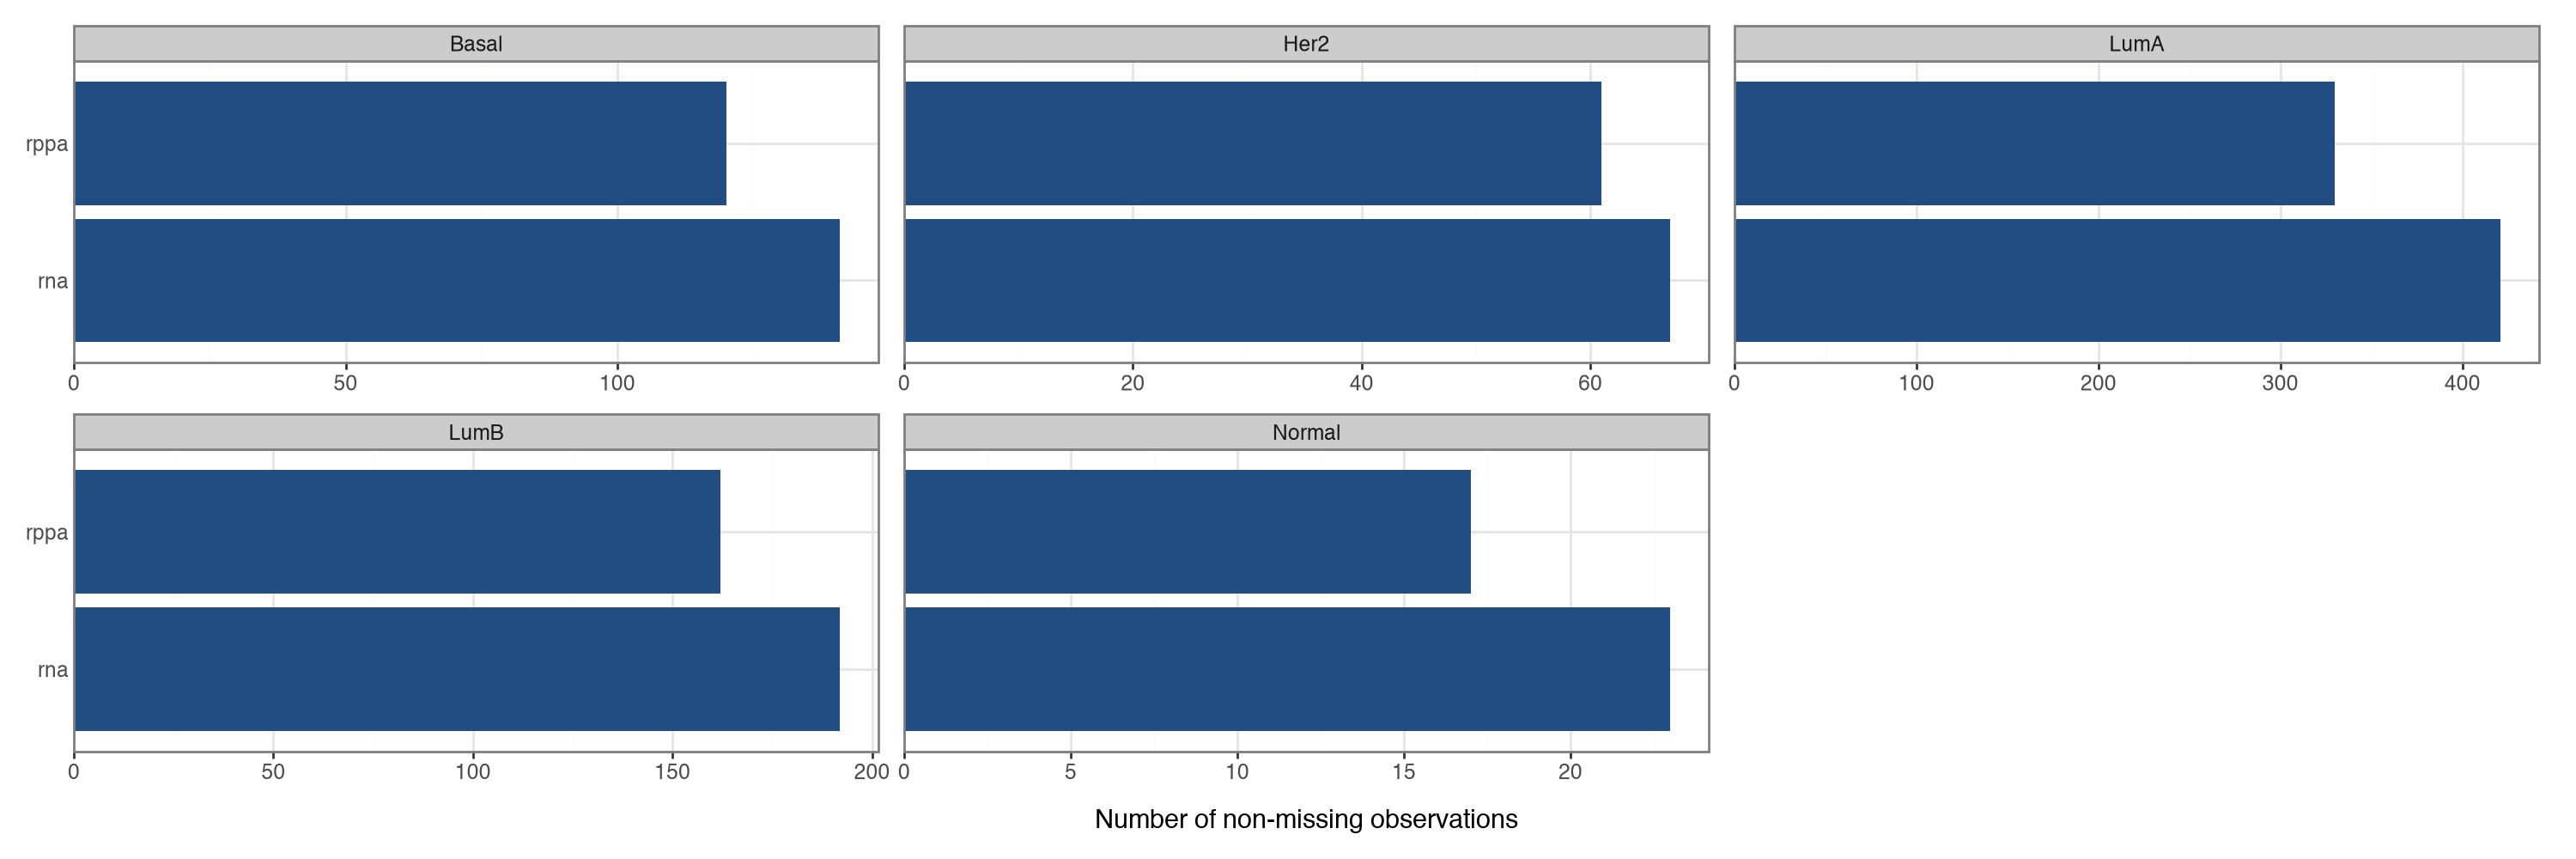

In [5]:
mfl.pl.overview(mdata, group_by="PAM50")

## Add Hallmark pathway annotations

We fetch the Hallmark gene sets from MSigDB, keep those with sufficient coverage among the selected genes, shorten their names for plotting, and store the resulting annotation matrix in `rna.varm`.

In [6]:
gene_set_collection = mfl.tl.msigdb_get_features(category="h.all", dbver="2025.1.Hs").filter(
    mdata["rna"].var_names, min_fraction=0.1, min_count=15, max_count=300
)

for gene_set in gene_set_collection:
    gene_set.name = gene_set.name.removeprefix("HALLMARK_").replace("_", " ").title()

gene_set_collection

<FeatureSets 'h.all.v2025.1.Hs.symbols' with 38 feature sets>

In [7]:
mdata["rna"].varm["gene_set_mask"] = gene_set_collection.to_mask(mdata["rna"].var_names.tolist()).T

## Train the model

We place an **informed Horseshoe** prior on the RNA weights, which gives the model one factor per Hallmark gene set: the annotation pulls each factor's RNA loadings towards its gene set, softly enough that the factor can still refine or move away from it. On top of these informed factors we add a single dense, uninformed factor (`n_factors=1`) to absorb the dominant axis of tumour variation so that it does not leak into the pathway factors. Non-negative factors and weights keep the loadings additive and interpretable, and the unannotated RPPA view shares the same factors, giving a protein-level readout of every program.

We train with a Normal likelihood on the preprocessed data. Training is deterministic (`seed=42`), so we save the fitted model once to a fixed path and simply reload it on re-runs; the analysis below always works from the model loaded on the CPU.

In [8]:
model_path = os.path.join(tempfile.gettempdir(), "mofaflex_brca.h5")
if not os.path.exists(model_path):
    mfl.terms.MofaFlex(
        n_factors=1,
        weight_prior=mfl.priors.InformedHorseshoe(annotations_mkey="gene_set_mask"),
        nonnegative_factors=True,
        nonnegative_weights=True,
        init_factors=0,
    ).fit(
        mdata,
        likelihoods=mfl.likelihoods.Normal(scale_per_group=False),
        plot_data_overview=False,
        save_path=model_path,
        seed=42,
    )

model = mfl.MOFAFLEX.load(model_path, map_location="cpu")

WARNING	The stored model was created with a different version of MOFA-FLEX. Some features may not work.


## Model diagnostics

We confirm the optimiser converged, then look at how variance is partitioned across the informed pathway factors. We pass a factor-name predicate that keeps factors present in the Hallmark annotation mask, dropping the single dense factor that absorbs the dominant axis of variation; each informed factor explains a smaller, pathway-specific slice.

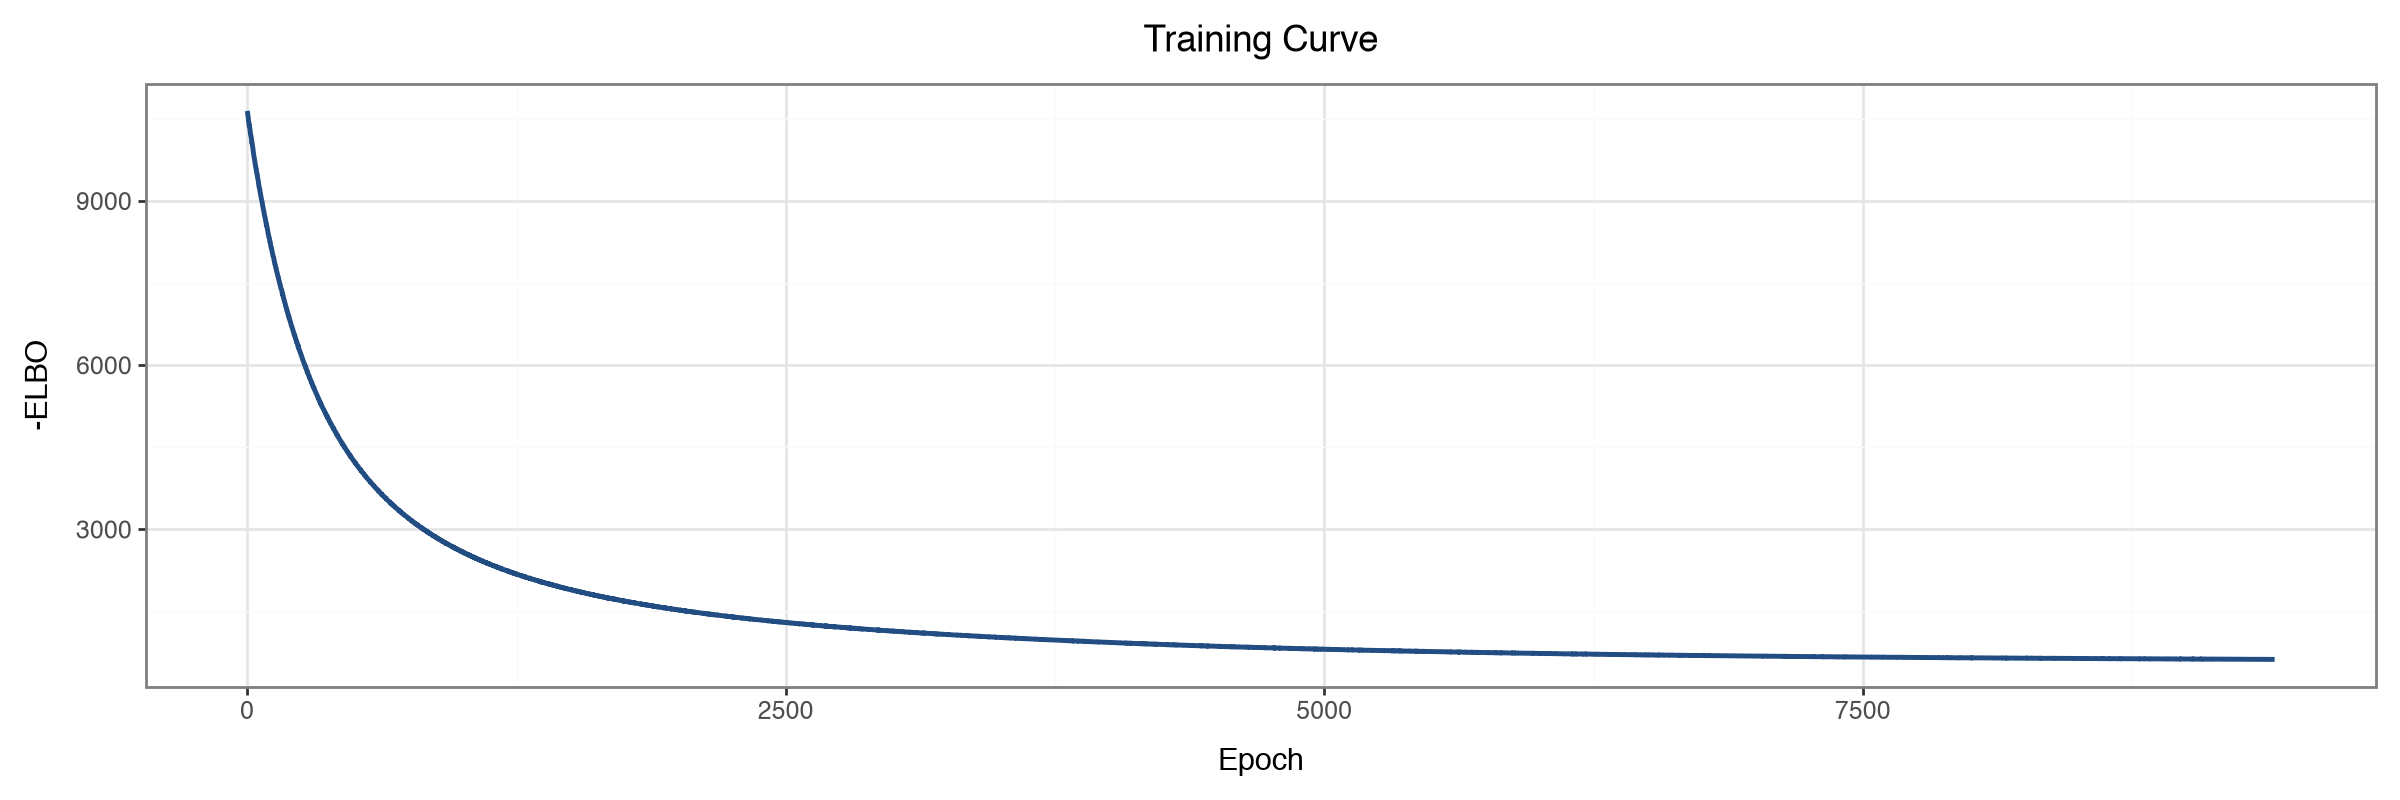

In [9]:
mfl.pl.training_curve(model)

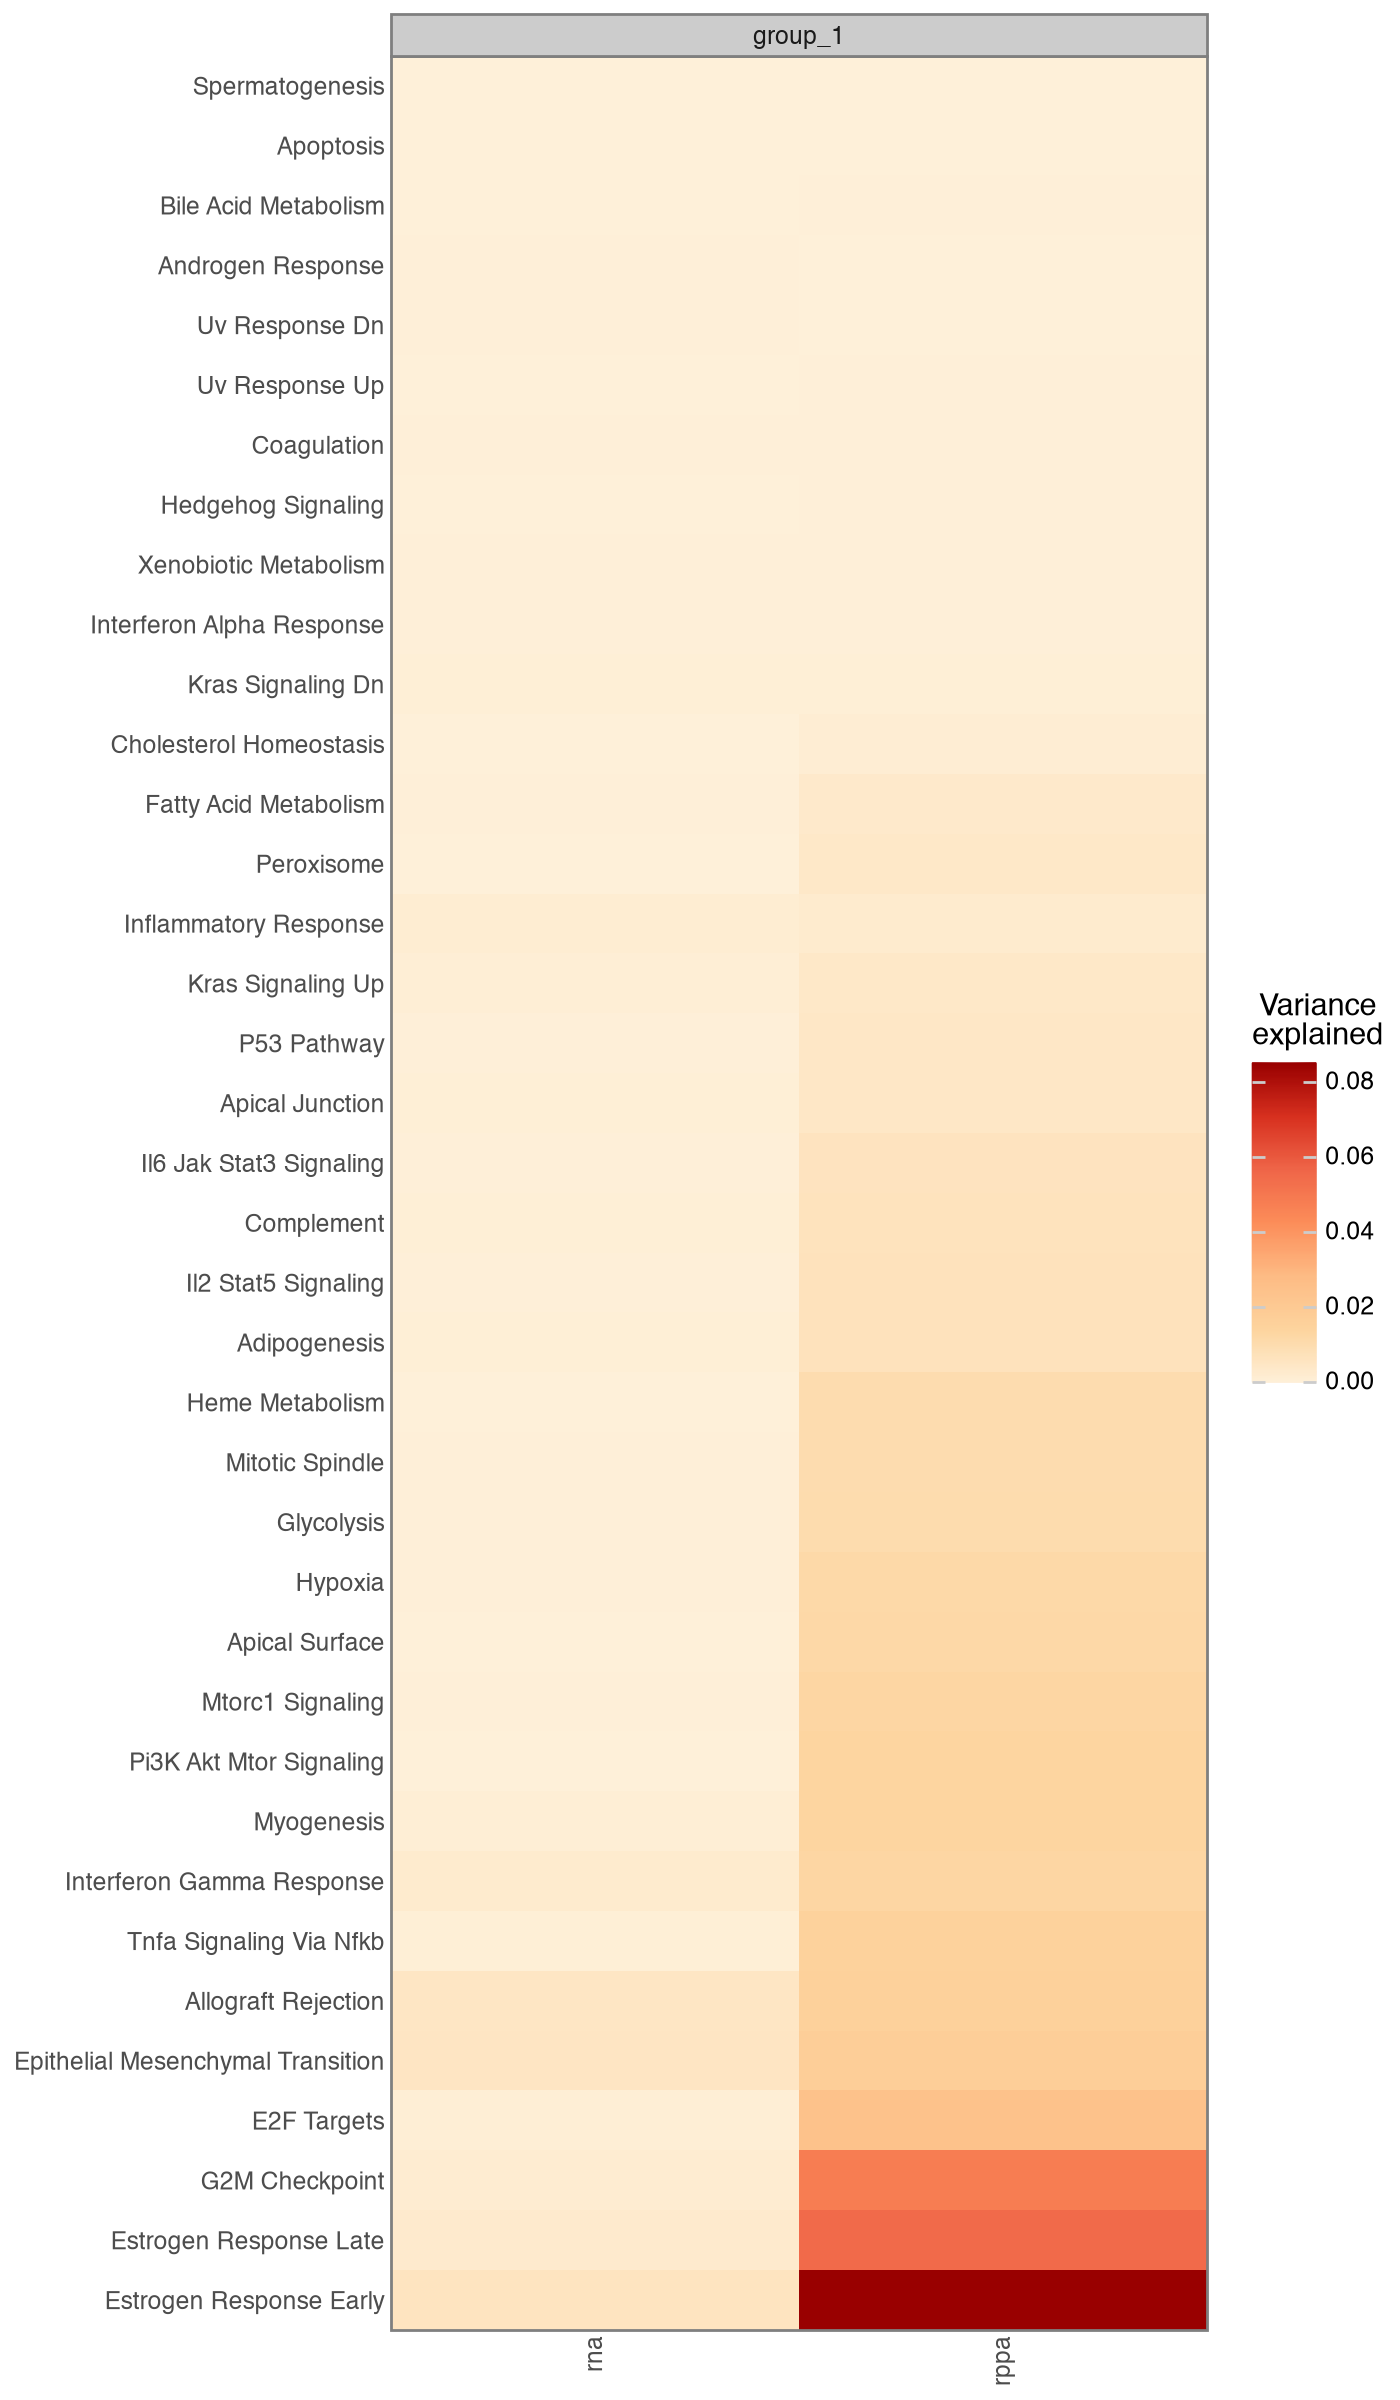

In [10]:
mfl.pl.variance_explained(
    model,
    factor_filter=lambda factor: factor in mdata["rna"].varm["gene_set_mask"].columns,
    figsize=(7, 12),
)

## Informed factors recover their pathways

The informed prior is soft, so we verify that each factor still reflects its gene set after training. The factor-significance plot runs PCGSE to test each informed RNA factor against its matching Hallmark gene set and ranks the factors by the variance they explain in the RNA view; strongly coloured points mark factors that stayed faithful to their annotation.

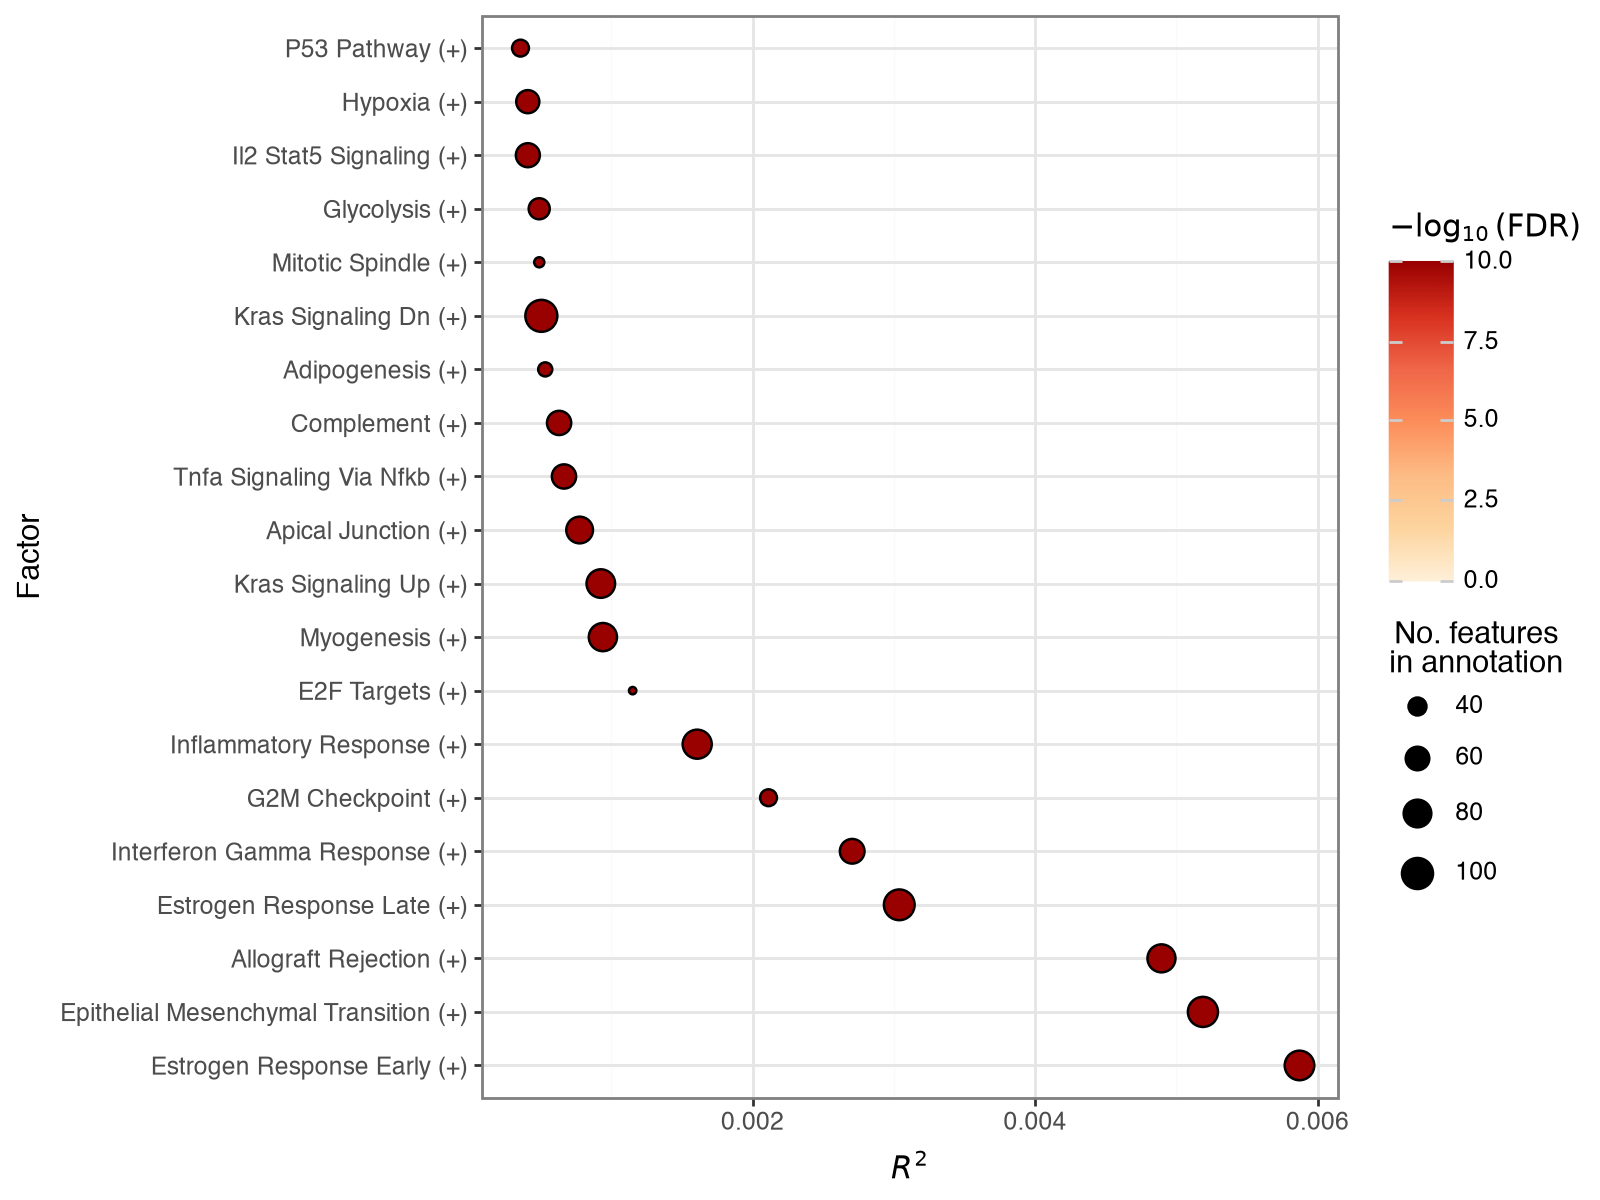

In [11]:
mfl.pl.factor_significance(model, views="rna", n_factors=20, figsize=(8, 6))

## Factors recapitulate PAM50 subtypes

The PAM50 subtype labels were not used during training. We assemble the factor scores into an `AnnData`, embed the samples with UMAP, and colour them by PAM50 subtype and by clinical ER status. The factors recover both: the subtypes occupy distinct regions and the ER-positive and ER-negative tumours largely separate along the embedding.

In [12]:
factors = model.get_factors()["group_1"]
pam50 = mdata.obs["PAM50"].reindex(factors.index)
er = mdata.obs["ER status"].reindex(factors.index)
informed_factors = [f for f in factors.columns if not f.startswith("Factor ")]

factor_adata = ad.AnnData(factors.astype("float32"))
factor_adata.obs["PAM50"] = pam50.values
factor_adata.obs["ER status"] = er.values
sc.pp.neighbors(factor_adata, use_rep="X", n_neighbors=15, random_state=0)
sc.tl.umap(factor_adata, random_state=0)

umap_df = pd.DataFrame(factor_adata.obsm["X_umap"], columns=["UMAP1", "UMAP2"], index=factors.index)
umap_df["PAM50"] = pam50.values
umap_df["ER status"] = er.values

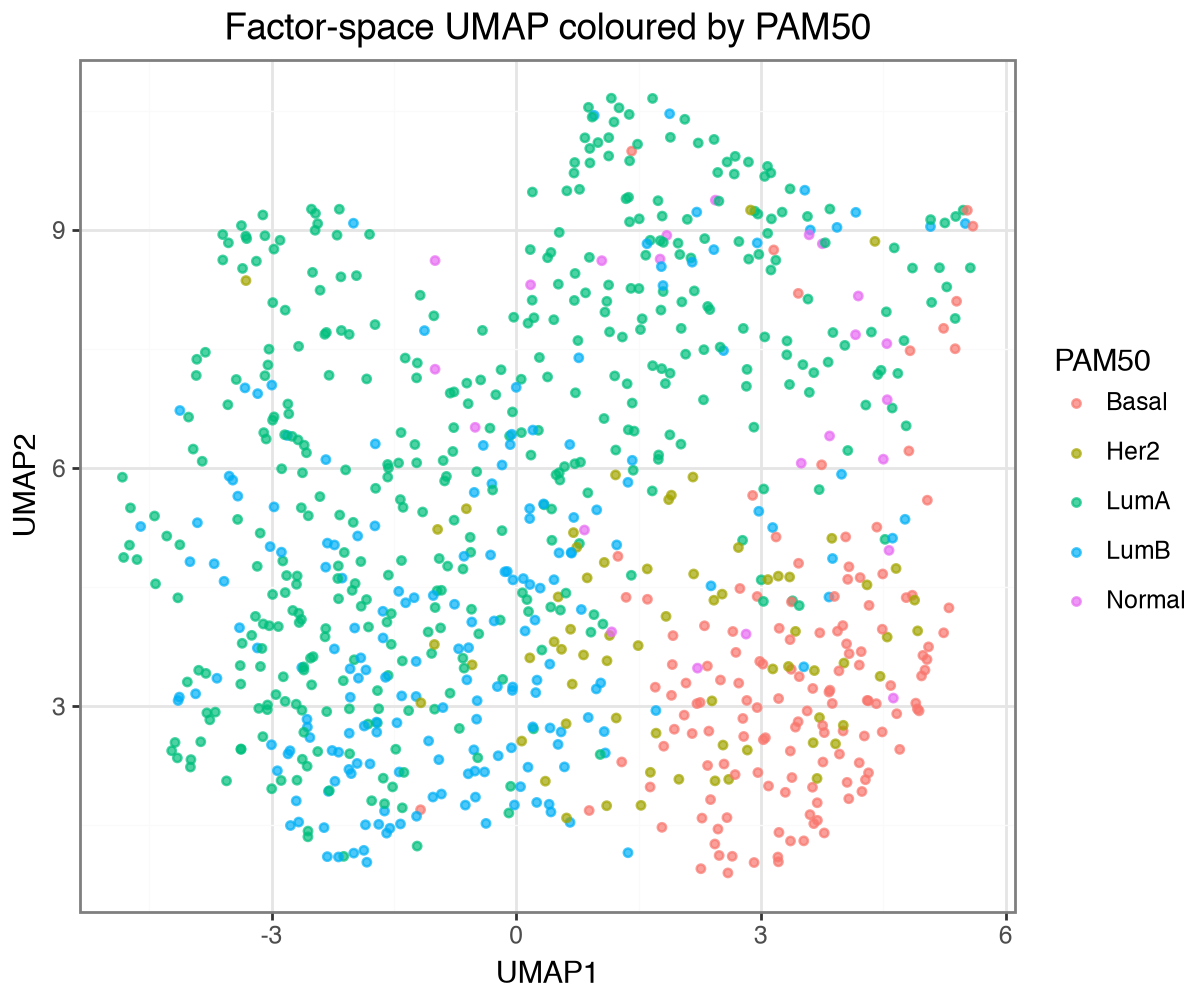

In [13]:
(
    ggplot(umap_df.dropna(subset=["PAM50"]), aes("UMAP1", "UMAP2", color="PAM50"))
    + geom_point(size=1.2, alpha=0.7)
    + labs(title="Factor-space UMAP coloured by PAM50")
    + theme(figure_size=(6, 5))
)

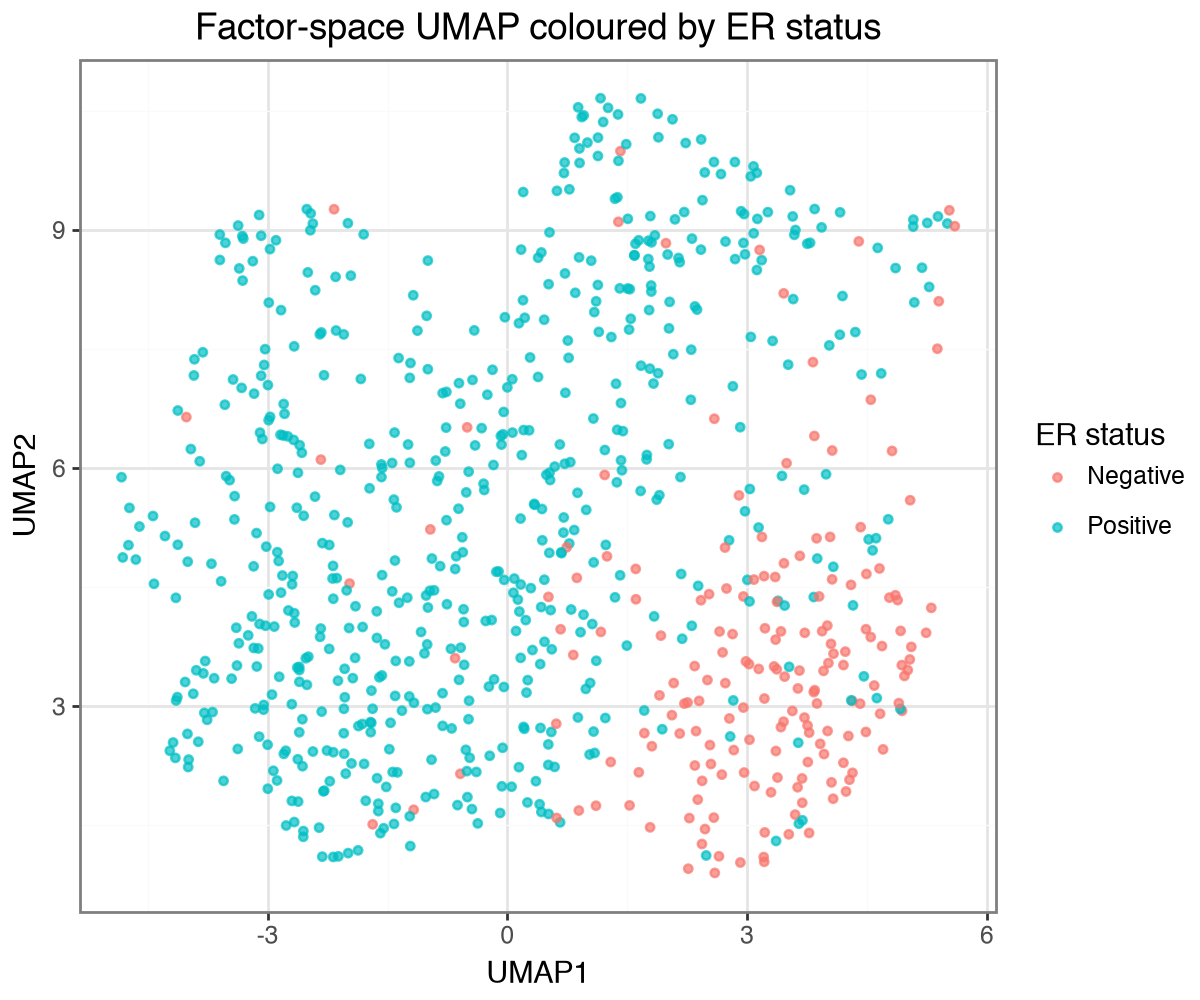

In [14]:
(
    ggplot(umap_df[umap_df["ER status"].isin(["Positive", "Negative"])], aes("UMAP1", "UMAP2", color="ER status"))
    + geom_point(size=1.2, alpha=0.7)
    + labs(title="Factor-space UMAP coloured by ER status")
    + theme(figure_size=(6, 5))
)

To name the programs that mark each subtype, we let the factors rank themselves. Because the factor scores are non-negative and far from normally distributed, we rank with a non-parametric Wilcoxon test, keep only the factors significantly up in a subtype (FDR < 0.05), and pick those with the highest log fold-change. The dot plot shows the best candidates per subtype, with dot colour the (per-factor scaled) mean score and dot size the fraction of tumours with non-zero activity.

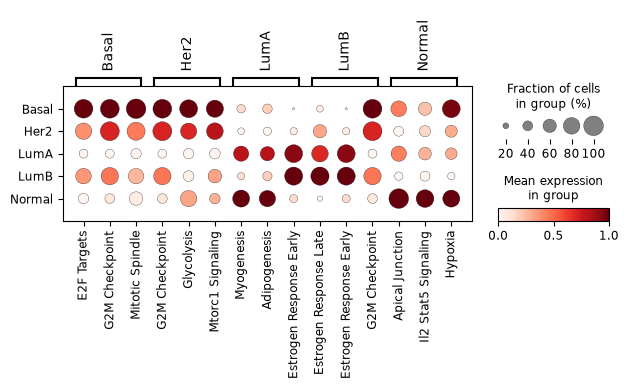

In [15]:
def rank(factor_adata, groupby, n_factors=3, var_subset=None, max_padj=0.05):
    """Rank factors per group with a non-parametric Wilcoxon test, keep the significant ones with the
    highest log fold-change, and dot-plot the best candidates per group. Returns the selected factors."""
    adata = factor_adata[factor_adata.obs[groupby].notna()].copy()
    if var_subset is not None:
        adata = adata[:, var_subset].copy()
    adata.obs[groupby] = adata.obs[groupby].astype("category").cat.remove_unused_categories()
    sc.tl.rank_genes_groups(adata, groupby, method="wilcoxon")
    ranked = sc.get.rank_genes_groups_df(adata, group=None)
    ranked = ranked[(ranked["pvals_adj"] < max_padj) & (ranked["logfoldchanges"] > 0)]
    selected = ranked.sort_values("logfoldchanges", ascending=False).groupby("group", observed=True).head(n_factors)
    var_names = {group: sub["names"].tolist() for group, sub in selected.groupby("group", observed=True)}
    sc.pl.dotplot(adata, var_names, groupby=groupby, standard_scale="var")
    return selected


pam50_pathways = rank(factor_adata, "PAM50", n_factors=3, var_subset=informed_factors)

We then compare the distribution of each selected pathway across all PAM50 subtypes.

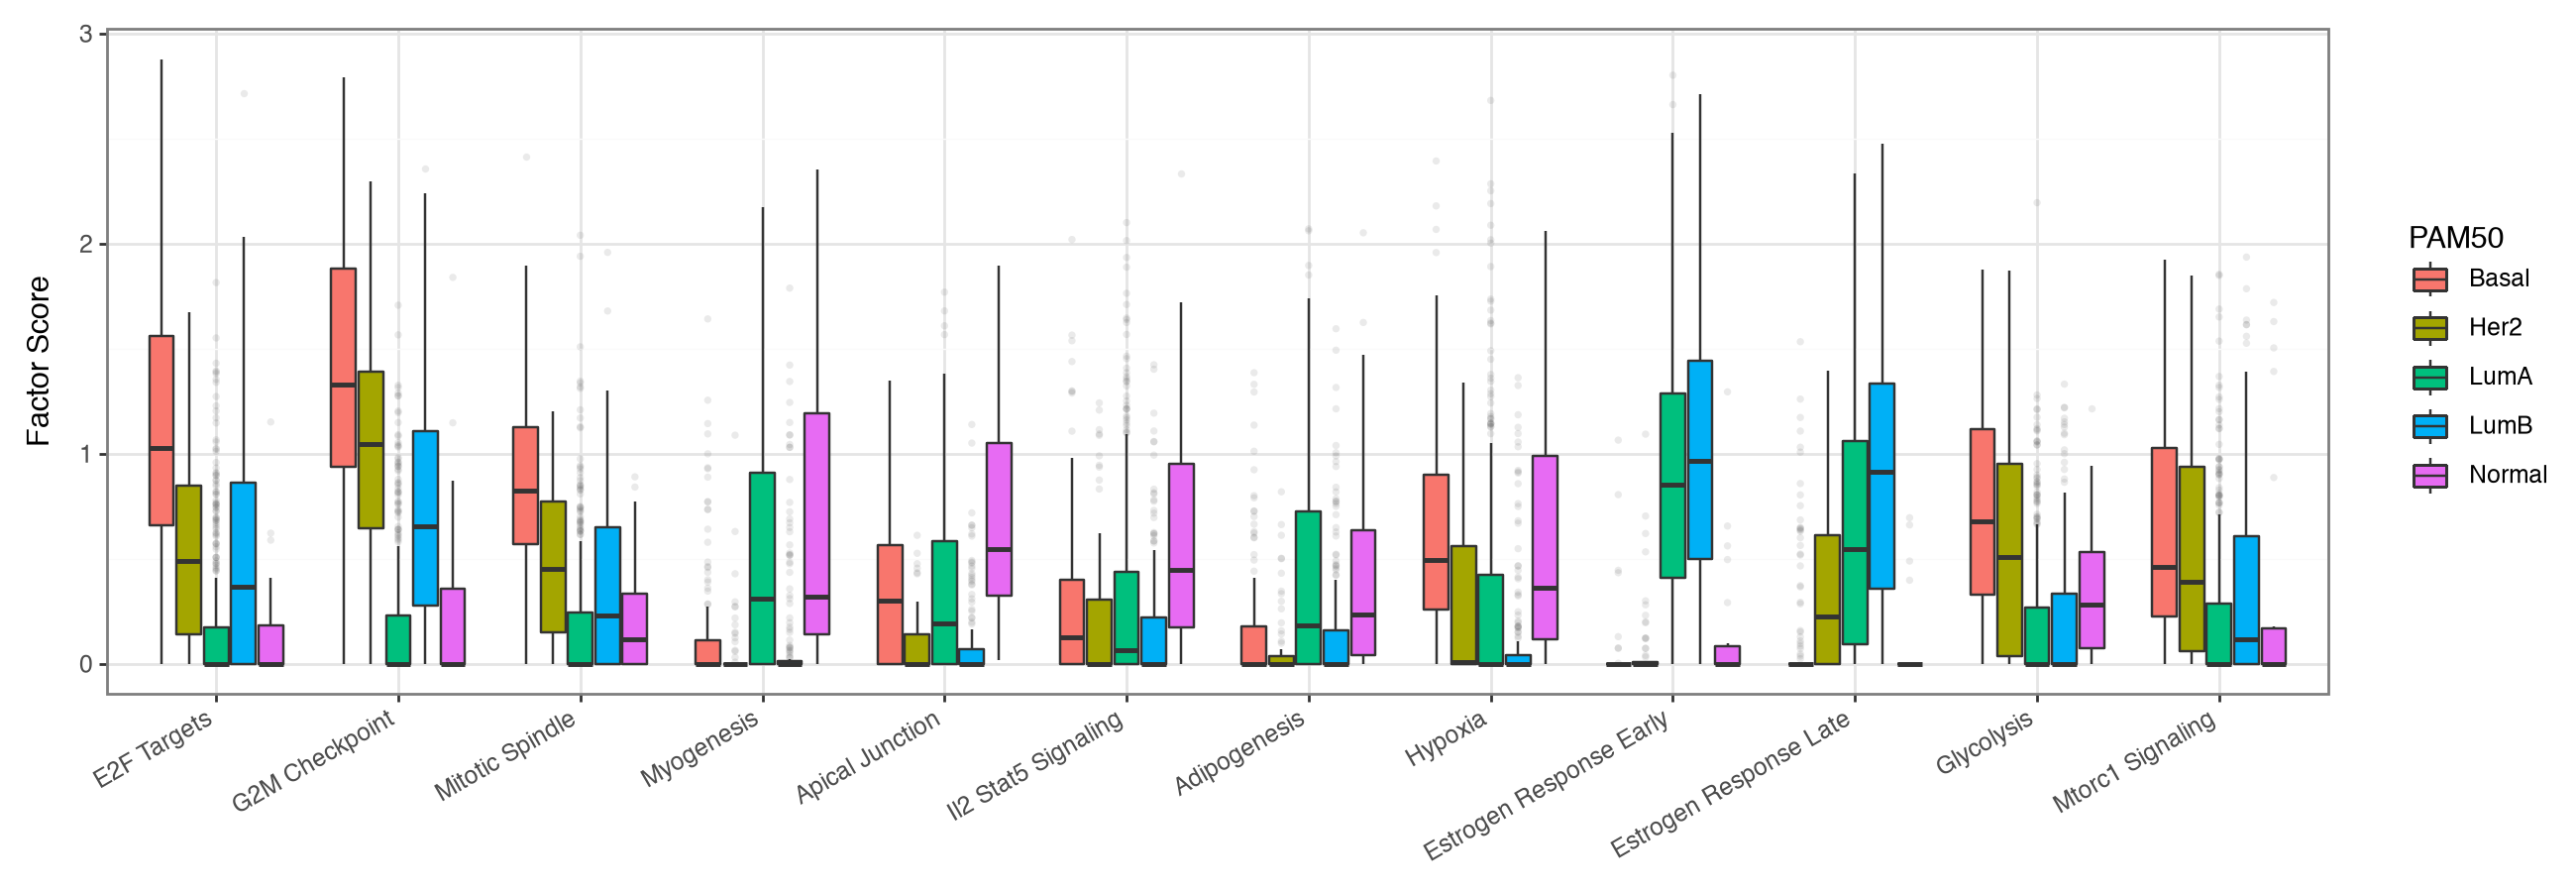

In [16]:
def pathway_boxplot(adata, pathways, groupby):
    df = (
        adata.to_df()[pathways]
        .assign(**{groupby: adata.obs[groupby]})
        .dropna(subset=[groupby])
        .melt(id_vars=[groupby], var_name="Factor", value_name="Factor Score")
    )
    df["Factor"] = pd.Categorical(df["Factor"], categories=pathways)
    return (
        ggplot(df, aes(x="Factor", y="Factor Score", fill=groupby))
        + geom_boxplot(outlier_alpha=0.1, outlier_stroke=0)
        + labs(x="")
        + theme(figure_size=(13, 4.5), axis_text_x=element_text(rotation=30, hjust=1))
    )


pathway_boxplot(factor_adata, pam50_pathways["names"].unique().tolist(), "PAM50")

## Pathways distinguishing ER status

We repeat the ranking across clinical ER status, restricted to the unambiguous ER-positive and ER-negative tumours. The same rank-based selection picks the programs most upregulated in each, and the boxplots show their distributions.

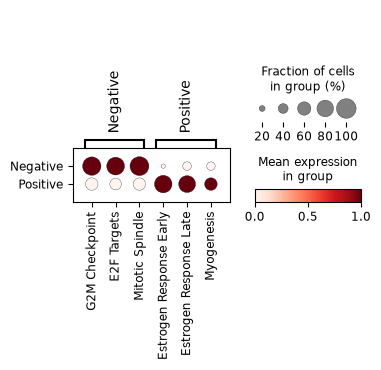

In [17]:
er_adata = factor_adata[factor_adata.obs["ER status"].isin(["Positive", "Negative"])].copy()
er_pathways = rank(er_adata, "ER status", n_factors=3, var_subset=informed_factors)

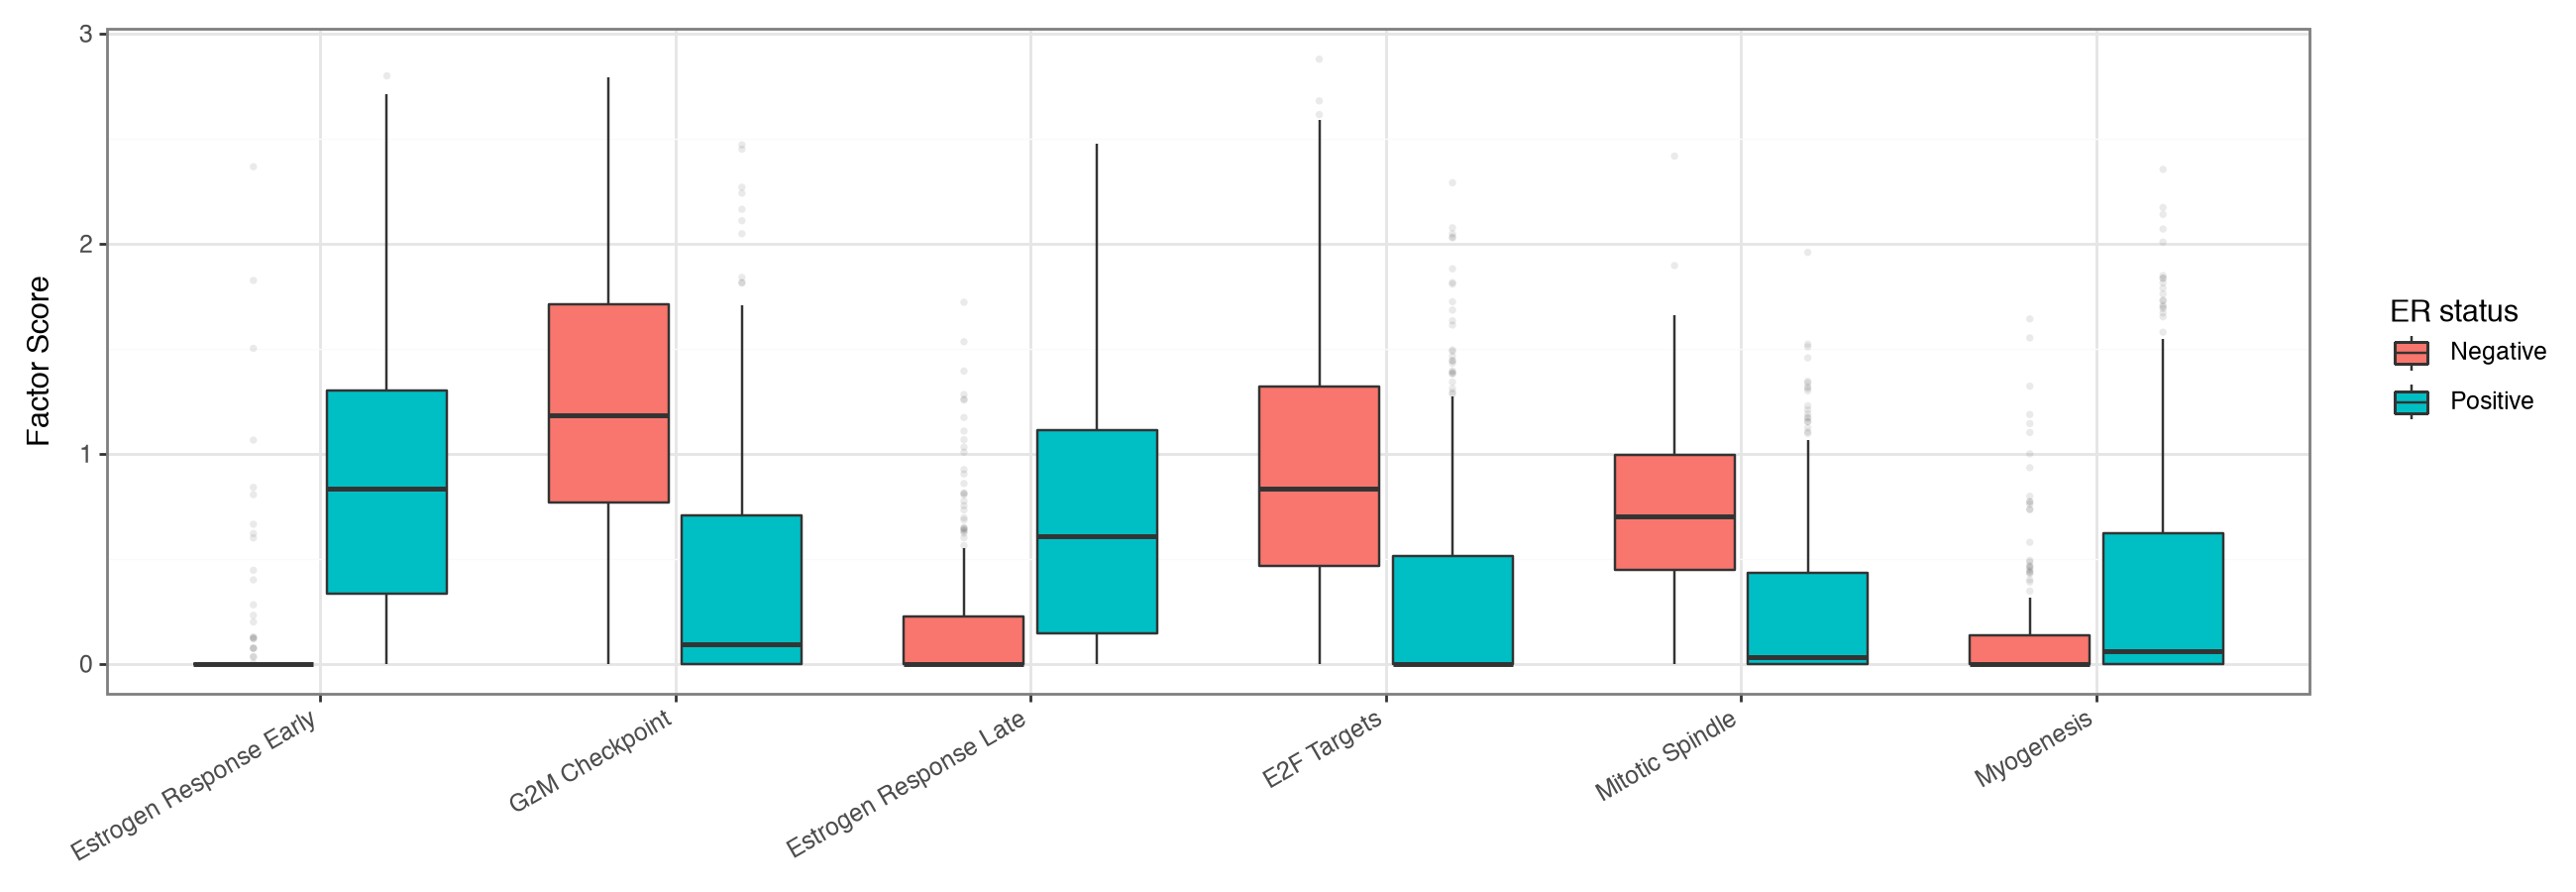

In [18]:
pathway_boxplot(er_adata, er_pathways["names"].unique().tolist(), "ER status")

## Prognostic value

Finally, we test whether the pathway factors carry prognostic information. For each factor we fit a univariate Cox proportional-hazards model for overall survival on the standardized factor score, so the hazard ratio is per standard deviation, and adjust the p-values across factors. The forest plot shows all factors, ranked by p-value, as hazard ratios with 95% confidence intervals.

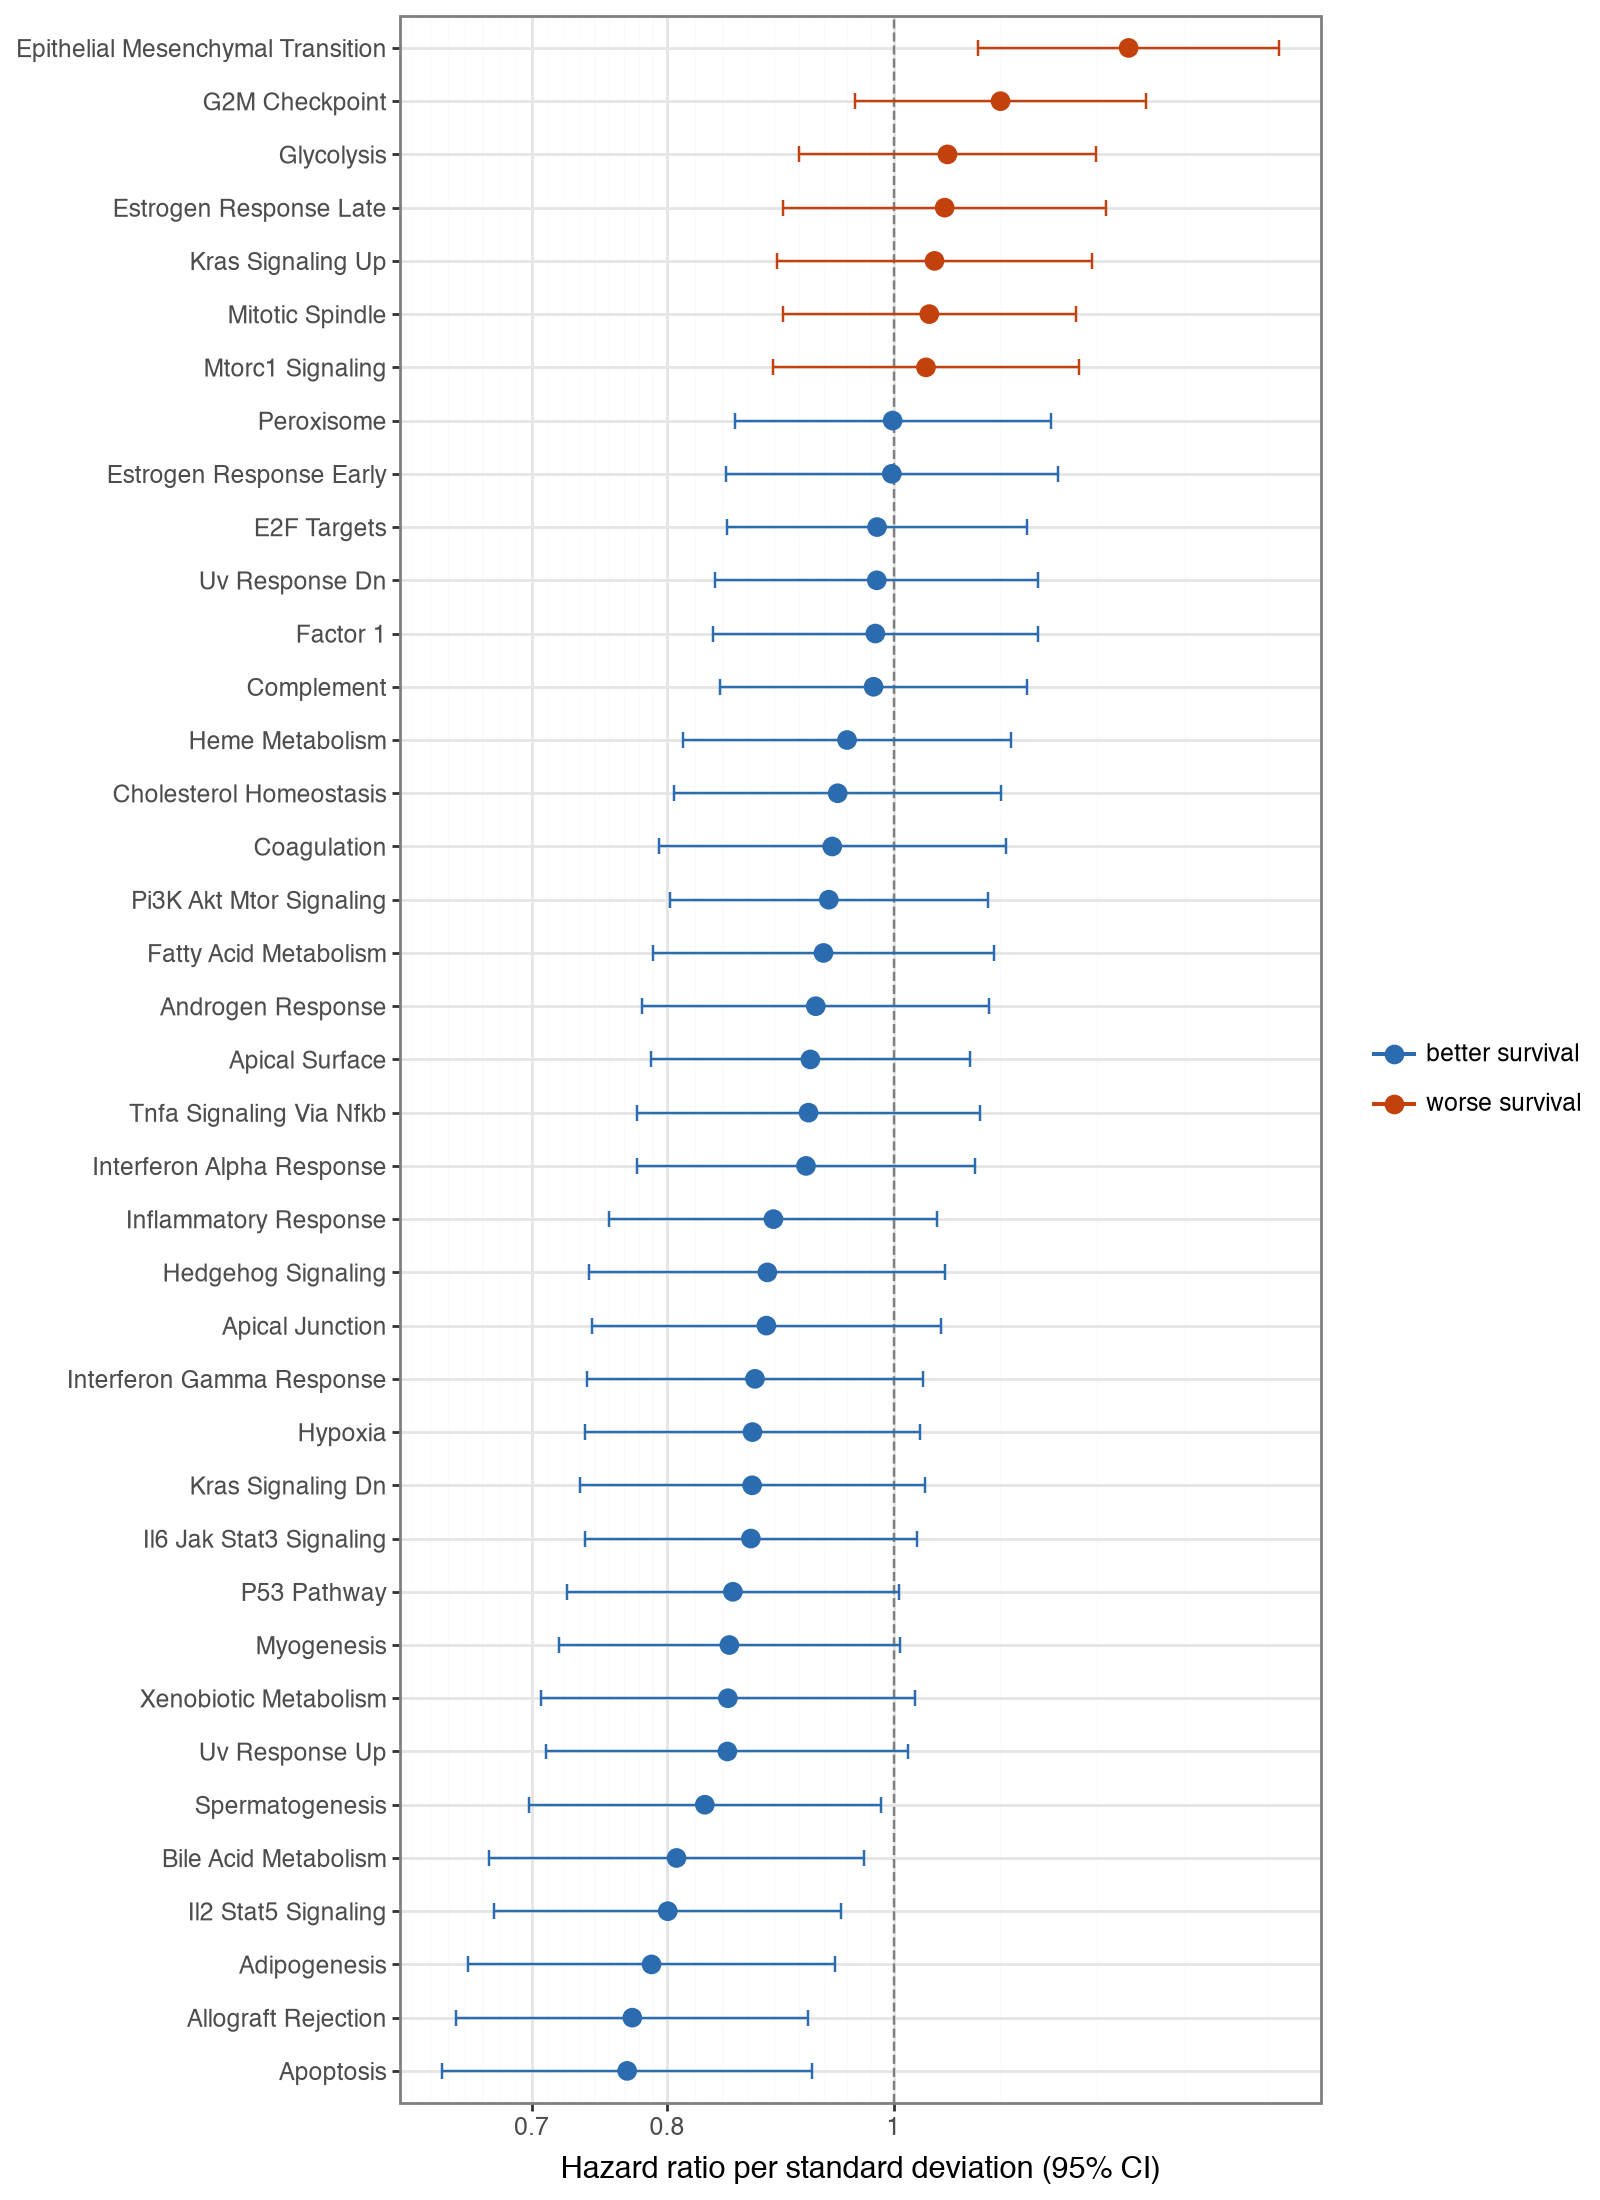

In [19]:
survival = factors.join(mdata.obs[["OS_time", "OS_event"]]).dropna(subset=["OS_time", "OS_event"])
survival = survival[survival["OS_time"] > 0]
standardized = (survival[factors.columns] - survival[factors.columns].mean()) / survival[factors.columns].std()

cox = []
for factor in factors.columns:
    fit = CoxPHFitter().fit(
        pd.DataFrame(
            {
                "T": survival["OS_time"].to_numpy(),
                "E": survival["OS_event"].to_numpy(),
                "x": standardized[factor].to_numpy(),
            }
        ),
        duration_col="T",
        event_col="E",
    )
    summary = fit.summary.loc["x"]
    cox.append(
        {
            "factor": factor,
            "HR": np.exp(summary["coef"]),
            "lower": np.exp(summary["coef lower 95%"]),
            "upper": np.exp(summary["coef upper 95%"]),
            "p": summary["p"],
        }
    )
cox = pd.DataFrame(cox)
cox["padj"] = multipletests(cox["p"], method="fdr_bh")[1]

forest = cox.sort_values("p").copy()
forest["factor"] = pd.Categorical(forest["factor"], categories=forest.sort_values("HR")["factor"])
forest["outcome"] = np.where(forest["HR"] > 1, "worse survival", "better survival")


(
    ggplot(forest, aes("HR", "factor", color="outcome"))
    + geom_vline(xintercept=1, linetype="dashed", color="gray")
    + geom_errorbarh(aes(xmin="lower", xmax="upper"), height=0.3)
    + geom_point(size=3)
    + scale_x_log10()
    + scale_color_manual({"worse survival": "#c2410c", "better survival": "#2b6cb0"})
    + labs(x="Hazard ratio per standard deviation (95% CI)", y="", color="")
    + theme(figure_size=(8, 11))
)

*Epithelial Mesenchymal Transition* is the strongest factor associated with worse outcome (hazard ratio > 1), consistent with its established link to invasion and metastasis, while several immune and apoptosis programs track better survival. The associations are nominal — none survives FDR correction across all factors (EMT has the smallest p-value, ≈0.002, but an adjusted p≈0.06) — which is expected for single pathway scores in bulk tumours. Splitting patients at the median of the EMT factor and comparing survival with a log-rank test confirms the separation.

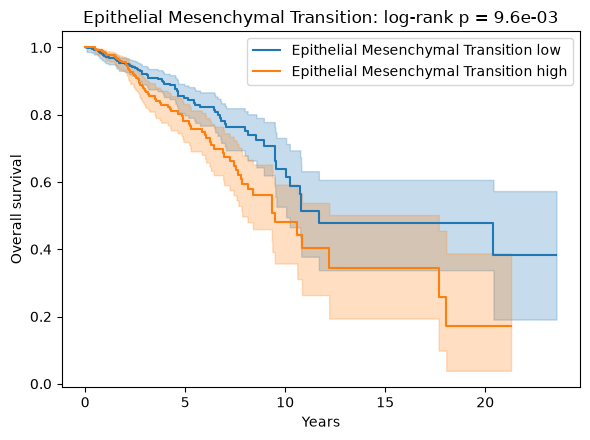

In [20]:
top_prognostic = cox.sort_values("p")["factor"].iloc[0]
group = np.where(survival[top_prognostic] > survival[top_prognostic].median(), "high", "low")

fig, ax = plt.subplots(figsize=(6, 4.5))
kmf = KaplanMeierFitter()
for level in ("low", "high"):
    mask = group == level
    kmf.fit(survival["OS_time"][mask] / 365.25, survival["OS_event"][mask], label=f"{top_prognostic} {level}")
    kmf.plot_survival_function(ax=ax)
result = logrank_test(
    survival["OS_time"][group == "high"],
    survival["OS_time"][group == "low"],
    survival["OS_event"][group == "high"],
    survival["OS_event"][group == "low"],
)
ax.set(xlabel="Years", ylabel="Overall survival", title=f"{top_prognostic}: log-rank p = {result.p_value:.1e}")
fig.tight_layout()
plt.show()

## Cross-modal coherence: protein corroborates RNA

The informed factors were shaped only by RNA gene sets, and the RPPA view was left unannotated, yet both modalities load on the same factors. We inspect a handful of programs spanning the biology above — the two proliferation factors, the two oestrogen-response factors, EMT, and apoptosis — and compare their top RNA loadings against their top RPPA loadings. For the informed RNA factors the plot distinguishes annotated genes from features the model added on its own.

In [21]:
explore_factors = [
    "Epithelial Mesenchymal Transition",
    "G2M Checkpoint",
    "E2F Targets",
    "Estrogen Response Early",
    "Estrogen Response Late",
    "Apoptosis",
]

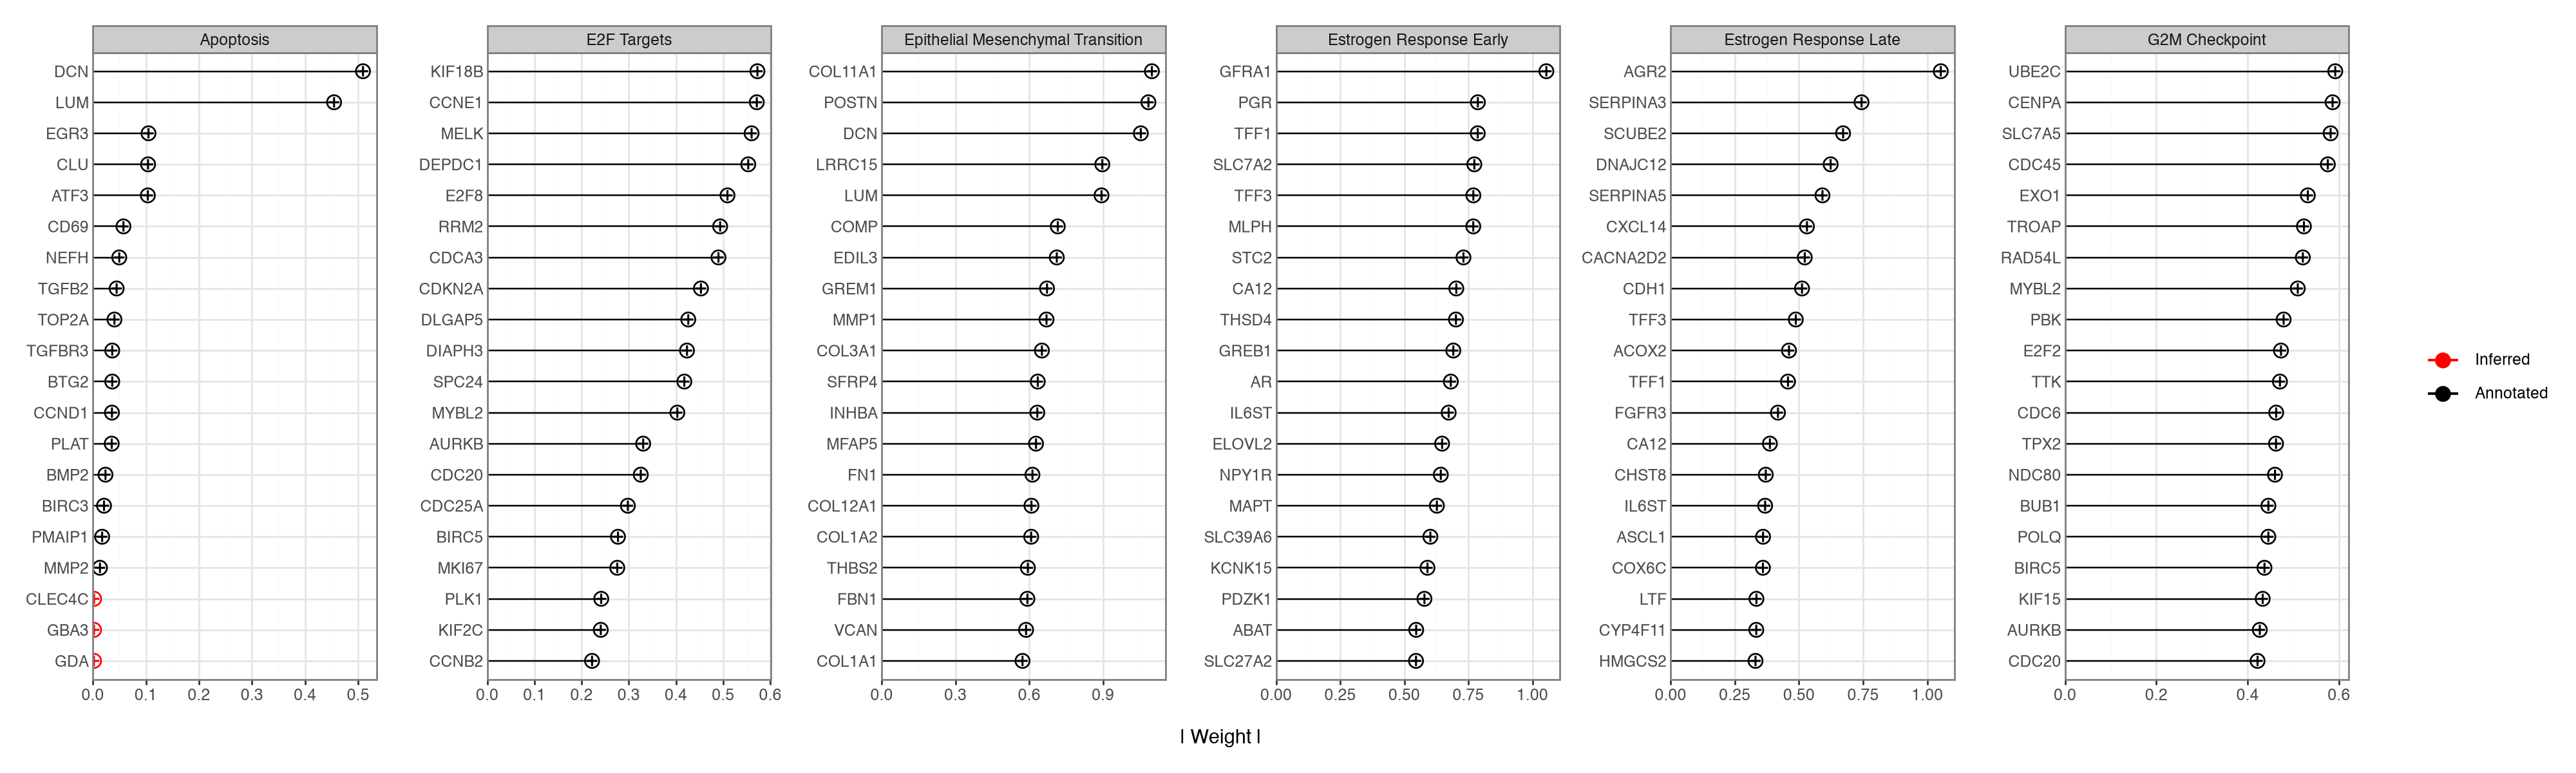

In [22]:
mfl.pl.top_weights(
    model, views="rna", factors=explore_factors, n_features=20, figsize=(20, 6), ncol=len(explore_factors)
)

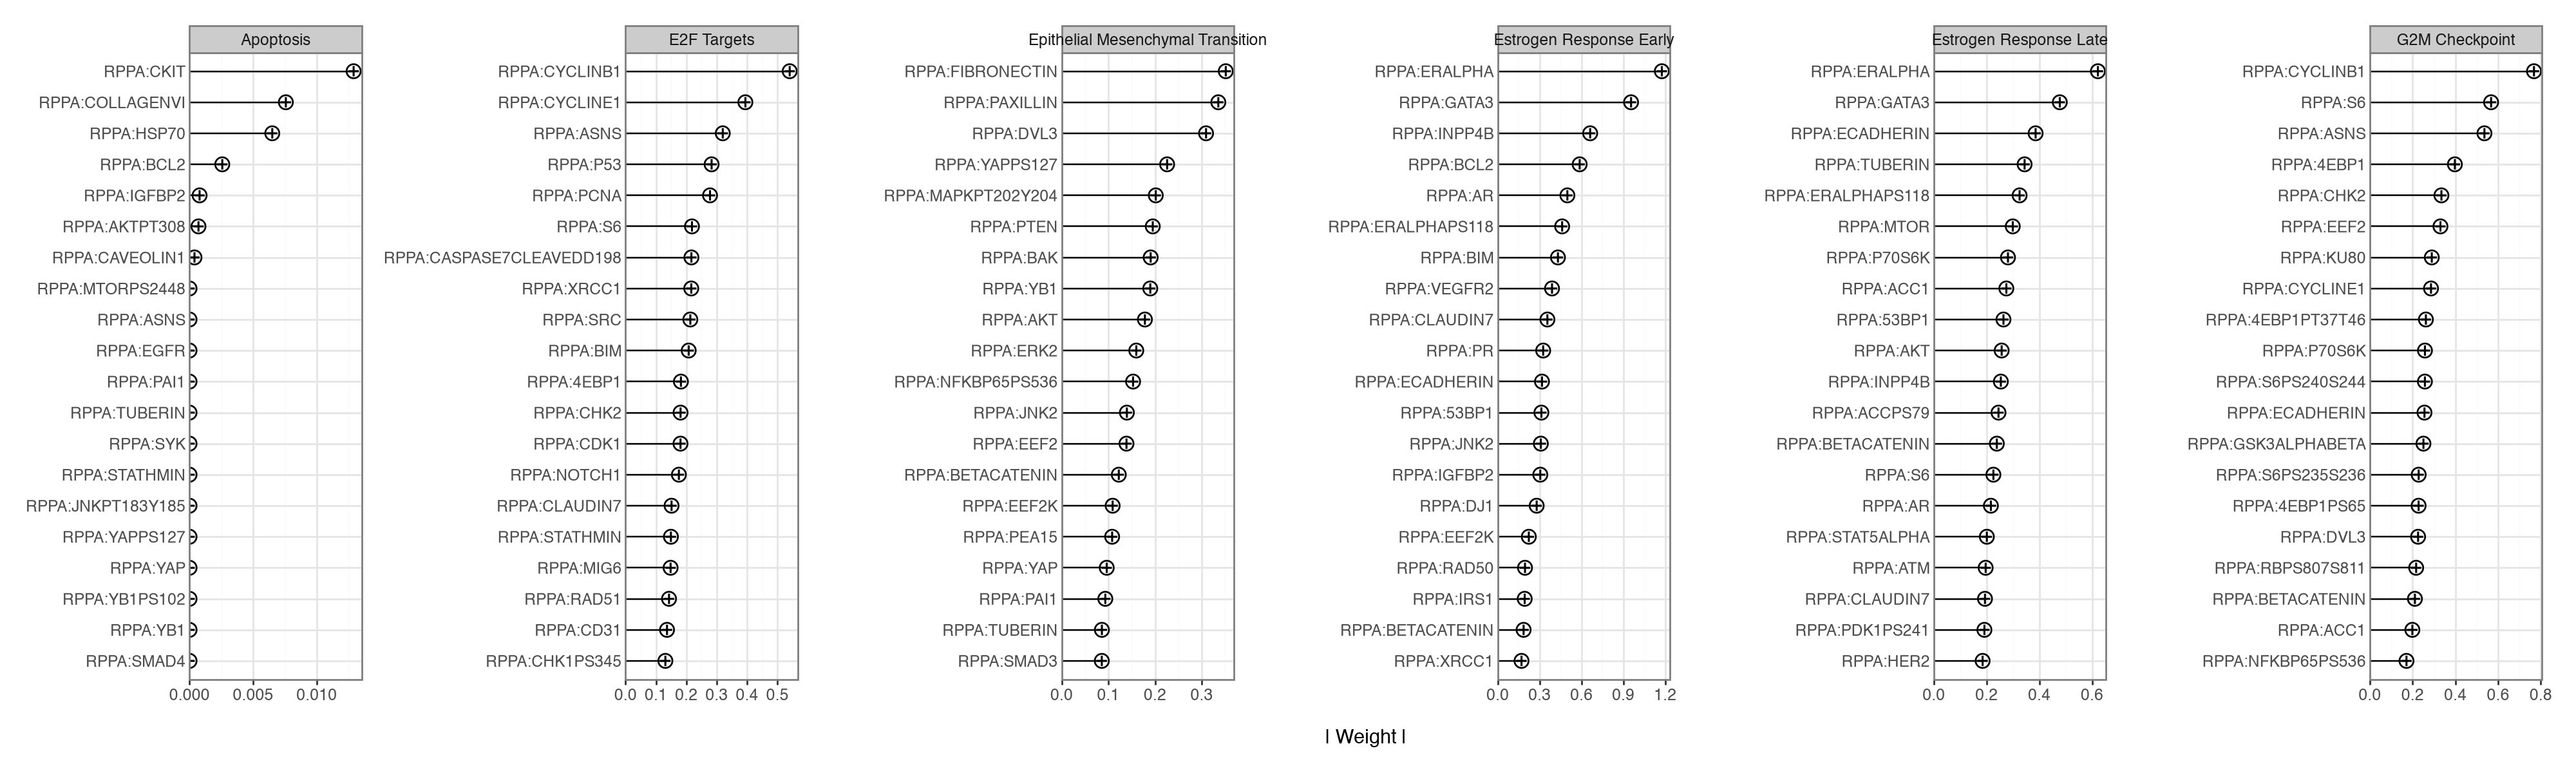

In [23]:
mfl.pl.top_weights(
    model, views="rppa", factors=explore_factors, n_features=20, figsize=(20, 6), ncol=len(explore_factors)
)

The protein loadings track the gene loadings without being told to. The proliferation factors (*G2M Checkpoint*, *E2F Targets*) load cell-cycle genes (*UBE2C*, *CCNE1*, *MELK*, *RRM2*) on the RNA side and cell-cycle proteins (Cyclin B1, Cyclin E1, PCNA) on the RPPA side; the oestrogen-response factors load hormone/luminal genes (*PGR*, *TFF1*, *AGR2*, *SCUBE2*) and hormone-receptor proteins (ER-alpha, GATA3, E-cadherin); and *Epithelial Mesenchymal Transition* loads extracellular-matrix genes (*COL11A1*, *POSTN*, *DCN*) together with the mesenchymal protein Fibronectin.

## Conclusion

A single informed MOFA-FLEX model turns bulk RNA and RPPA into a set of named, pathway-anchored factors. The informed factors recover their Hallmark pathways; without ever seeing the labels, they reconstruct the PAM50 subtypes and agree with clinical receptor status; they stratify overall survival, with the EMT program flagging worse-prognosis tumours; and their protein loadings independently reproduce the RNA biology, with hormone-receptor proteins on the oestrogen factors and cell-cycle proteins on the proliferation factors. The informed prior is what makes this readable: it yields interpretable, pathway-level factors, while the single dense factor keeps the dominant luminal axis from contaminating them.